# 08 · From a Better Model to Better Control

The last five chapters compared models purely by prediction error. But models are rarely the end
goal; we want to *act*. This chapter asks the question a control engineer actually cares about: does
a better-identified model translate into a better-controlled system?

---
## 1. Feedforward control from a model

As a simple model-based controller, we compute a **feedforward input** that should move the cart
along a reference trajectory $r_t$, by solving

$$
u^\star = \arg\min_{u}\ \sum_t \big(\hat q_t(\hat\eta; u) - r_t\big)^2 + \lambda\sum_t (u_{t+1}-u_t)^2
$$

with each candidate model, and then apply $u^\star$ to the **true** system. Feedforward cannot
correct errors while running, so it is a direct test of model quality. The context models use a
designed 6-second experiment (chapter 06).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dynutils
from dynutils import sample_system, simulate, multisine, predict, adapt, design_score, rmse

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR = dynutils.COLOR
family, train_systems, train_data, train_fits = dynutils.build_family(rng)

In [2]:
T_ctrl = 120
tc = dynutils.DT * np.arange(T_ctrl + 1)
ref = 0.2 - 0.35 * (1 / (1 + np.exp(-(tc - 3) * 3))) + 0.25 * (1 / (1 + np.exp(-(tc - 8) * 3)))


def feedforward(eta, lam=0.05, eps=1e-5):
    return dynutils.feedforward(eta, ref, lam=lam, eps=eps)

---
## 2. Tracking a new system

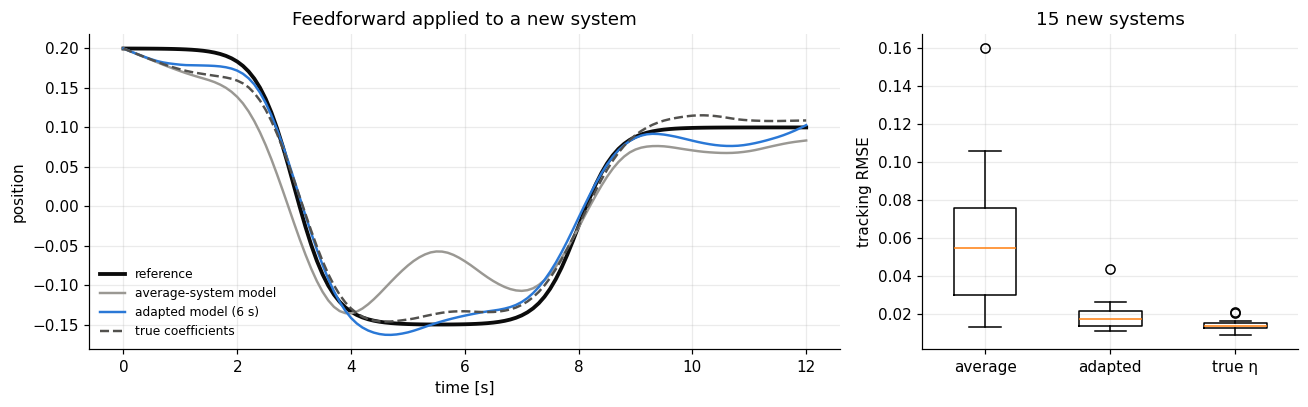

  average-system model: mean tracking RMSE = 0.0577
   adapted model (6 s): mean tracking RMSE = 0.0191
     true coefficients: mean tracking RMSE = 0.0140


In [3]:
pool = np.array([multisine(60, rng) for _ in range(200)])
u_design = pool[np.argmax(design_score(family, pool))]
ctrl_err = {m: [] for m in ("none", "context", "reference")}
ctrl_example = {}
for n in range(15):
    s = sample_system(rng)
    z_, _, _ = adapt(family, simulate(s, u_design, rng)[1], u_design)
    for m, eta in (("none", family.mean), ("context", family.decode(z_)), ("reference", s["eta"])):
        q_ctrl, _ = simulate(s, feedforward(eta), rng)
        ctrl_err[m].append(rmse(q_ctrl, ref))
        if n == 0:
            ctrl_example[m] = q_ctrl

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw=dict(width_ratios=[2, 1]))
ax1.plot(tc, ref, color=COLOR["truth"], lw=2.5, label="reference")
lab = dict(none="average-system model", context="adapted model (6 s)", reference="true coefficients")
for m, q_ctrl in ctrl_example.items():
    ax1.plot(tc, q_ctrl, "--" if m == "reference" else "-", color=COLOR[m], lw=1.6, label=lab[m])
ax1.set(xlabel="time [s]", ylabel="position", title="Feedforward applied to a new system"); ax1.legend(fontsize=8)
ax2.boxplot([ctrl_err[m] for m in ctrl_err], tick_labels=["average", "adapted", "true η"], widths=0.5)
ax2.set(ylabel="tracking RMSE", title="15 new systems")
plt.tight_layout(); plt.show()
for m in ctrl_err:
    print(f"{lab[m]:>22s}: mean tracking RMSE = {np.mean(ctrl_err[m]):.4f}")

Six seconds of well-chosen data, interpreted through the pretrained family, cut the tracking error
by more than half compared with the average-system model, and match what the true coefficients
achieve. The adapted model can even be marginally better, because it is fitted to the real
behaviour and partly absorbs the unmodelled terms. The remaining error comes from the disturbance,
which only feedback can reject. A feedback controller would reduce all errors, but the ordering,
and the reason for it, would remain.

---
## Exercises

### Exercise 1: A random experiment instead of a designed one
Repeat the control comparison, but adapt the context from a random 6-second experiment
(`multisine(60, rng)`) instead of the D-optimal `u_design`. Does the "context" tracking error move
noticeably closer to "average" or stay close to "true η"?

<details><summary>Solution</summary>

```python
ctrl_err_random = []
for n in range(15):
    s = sample_system(rng)
    u_random = multisine(60, rng)
    z_, _, _ = adapt(family, simulate(s, u_random, rng)[1], u_random)
    q_ctrl, _ = simulate(s, feedforward(family.decode(z_)), rng)
    ctrl_err_random.append(rmse(q_ctrl, ref))
np.mean(ctrl_err_random), np.mean(ctrl_err["context"])
```
Consistent with chapter 06, the random experiment still gives a usable adapted model (context
adaptation degrades gracefully), but its mean tracking error sits above the designed experiment's,
closer to the midpoint between "average" and "true η" rather than matching "true η" outright.
</details>

### Exercise 2: A heavier smoothness penalty
Recompute the feedforward input for the true-coefficient model with `lam=0.5` instead of `0.05` (ten
times more smoothing). How does the resulting input and the tracking error change?

<details><summary>Solution</summary>

```python
s = sample_system(rng)
u_smooth = feedforward(s["eta"], lam=0.5)
q_smooth, _ = simulate(s, u_smooth, rng)
rmse(q_smooth, ref)
```
A heavier smoothness penalty produces a gentler input that changes less from sample to sample, at
the cost of tracking the sharp step in the reference less closely: the feedforward optimisation
trades tracking accuracy for input smoothness exactly as `lam` dictates, independently of which
model supplied `eta`.
</details>